In [26]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

In [27]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

1000 20_newsgroups/rec.motorcycles
1000 20_newsgroups/comp.sys.ibm.pc.hardware
1000 20_newsgroups/comp.windows.x
1000 20_newsgroups/comp.os.ms-windows.misc
1000 20_newsgroups/rec.sport.baseball
1000 20_newsgroups/sci.electronics
1000 20_newsgroups/misc.forsale
1000 20_newsgroups/sci.crypt
1000 20_newsgroups/comp.graphics
1000 20_newsgroups/sci.med
1000 20_newsgroups/alt.atheism
1000 20_newsgroups/talk.politics.guns
1000 20_newsgroups/sci.space
1000 20_newsgroups/talk.politics.misc
1000 20_newsgroups/talk.politics.mideast
1000 20_newsgroups/rec.autos
1000 20_newsgroups/rec.sport.hockey
997 20_newsgroups/soc.religion.christian
1000 20_newsgroups/comp.sys.mac.hardware
1000 20_newsgroups/talk.religion.misc


In [28]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    
    corpus_text = " ".join(token)
    return corpus_text, len(token)

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

max_features = 0

for data_point in data:
    tokens, length = clean_text(data_point["text"])
    max_features = max(length, max_features)
    data_point["corpus_text"] = tokens

corpus = [dp["corpus_text"] for dp in data]
vectorizor = TfidfVectorizer(max_features=max_features, ngram_range=(1,2))
X = vectorizor.fit_transform(corpus)
y = [d["label"] for d in data]

In [29]:
model = LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10, 100]
,cv=5,dual=False,penalty="l2",solver="lbfgs",multi_class="multinomial",verbose=True,tol=1e-4,max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y,shuffle=True)
model.fit(X_train,y_train)

/home/nikunj/miniconda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   33.0s finished


,Cs,"[0.001, 0.01, ...]"
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [30]:
print(model.score(X_test,y_test))
# print(model.coef_)
# print(model.intercept_)
# print(model.C_)
# print(model.scores_)

0.9545


['rec.motorcycles', 'comp.sys.ibm.pc.hardware', 'comp.windows.x', 'comp.os.ms-windows.misc', 'rec.sport.baseball', 'sci.electronics', 'misc.forsale', 'sci.crypt', 'comp.graphics', 'sci.med', 'alt.atheism', 'talk.politics.guns', 'sci.space', 'talk.politics.misc', 'talk.politics.mideast', 'rec.autos', 'rec.sport.hockey', 'soc.religion.christian', 'comp.sys.mac.hardware', 'talk.religion.misc']


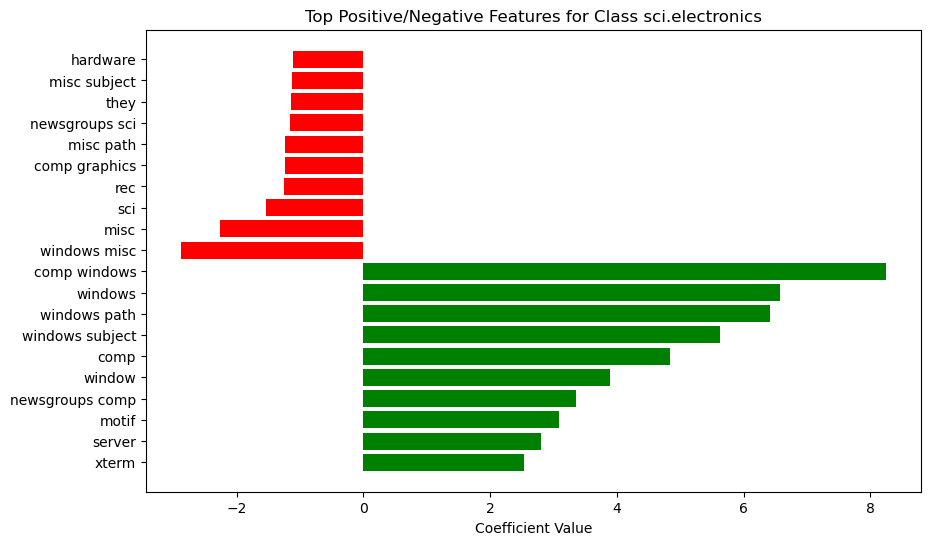

In [31]:
feature_names = vectorizor.get_feature_names_out()
top_n = 10
class_index = 5
print(classes)
coefs = model.coef_[class_index]
top_pos_indices = np.argsort(coefs)[-top_n:]
top_neg_indices = np.argsort(coefs)[:top_n]

plt.figure(figsize=(10,6))
plt.barh(range(top_n), coefs[top_pos_indices], color='green')
plt.barh(range(top_n, 2*top_n), coefs[top_neg_indices], color='red')
plt.yticks(range(2*top_n), 
           [feature_names[i] for i in list(top_pos_indices)+list(top_neg_indices)])
plt.xlabel("Coefficient Value")
plt.title(f"Top Positive/Negative Features for Class {classes[class_index]}")
plt.show()


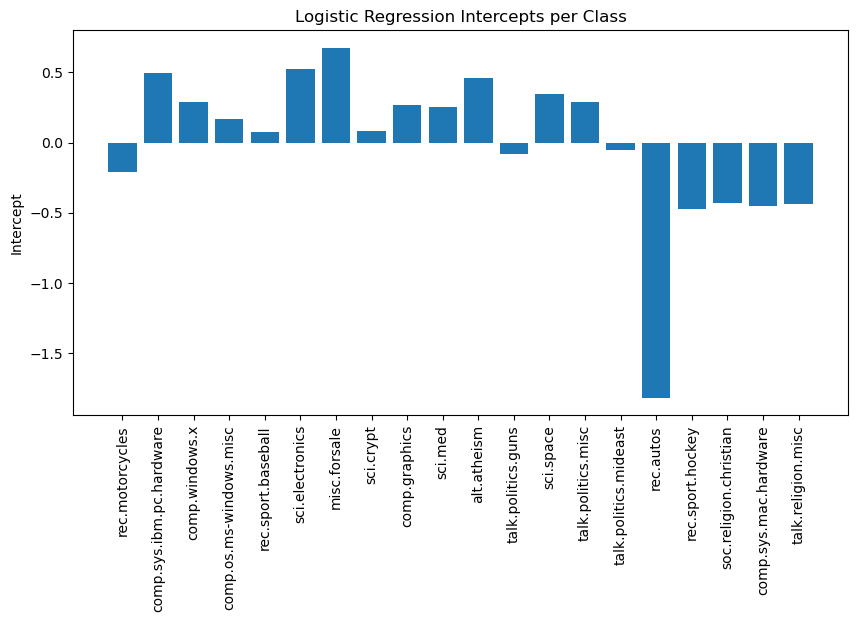

In [32]:
plt.figure(figsize=(10,5))
plt.bar(classes, model.intercept_)
plt.xticks(rotation=90)
plt.ylabel("Intercept")
plt.title("Logistic Regression Intercepts per Class")
plt.show()


In [33]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for index, doc in enumerate(X_test):
    prediction = model.predict(doc)
    i = classes.index(prediction[0])
    j = classes.index(y_test[index]) 
    confusion_matrix[i][j] +=1
    if (y_test[index] == prediction):
        total_accuracy+=1
print("Accuracy: ",total_accuracy / X_test.shape[0])
y_pred = model.predict(X_test)

print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Micro F1:", f1_score(y_test, y_pred, average='micro'))

print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy:  0.9545
Macro F1: 0.9545332374582676
Micro F1: 0.9545
Macro Precision: 0.954747737770641
Macro Recall: 0.9545
Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.87      0.82      0.84       300
           comp.graphics       0.98      0.99      0.99       300
 comp.os.ms-windows.misc       0.98      0.96      0.97       300
comp.sys.ibm.pc.hardware       0.95      0.99      0.97       300
   comp.sys.mac.hardware       0.99      0.99      0.99       300
          comp.windows.x       0.97      0.99      0.98       300
            misc.forsale       0.98      0.96      0.97       300
               rec.autos       0.99      0.99      0.99       300
         rec.motorcycles       1.00      1.00      1.00       300
      rec.sport.baseball       0.99      1.00      1.00       300
        rec.sport.hockey       1.00      0.99      0.99       300
               sci.crypt       0.99      0.99      0.99       3

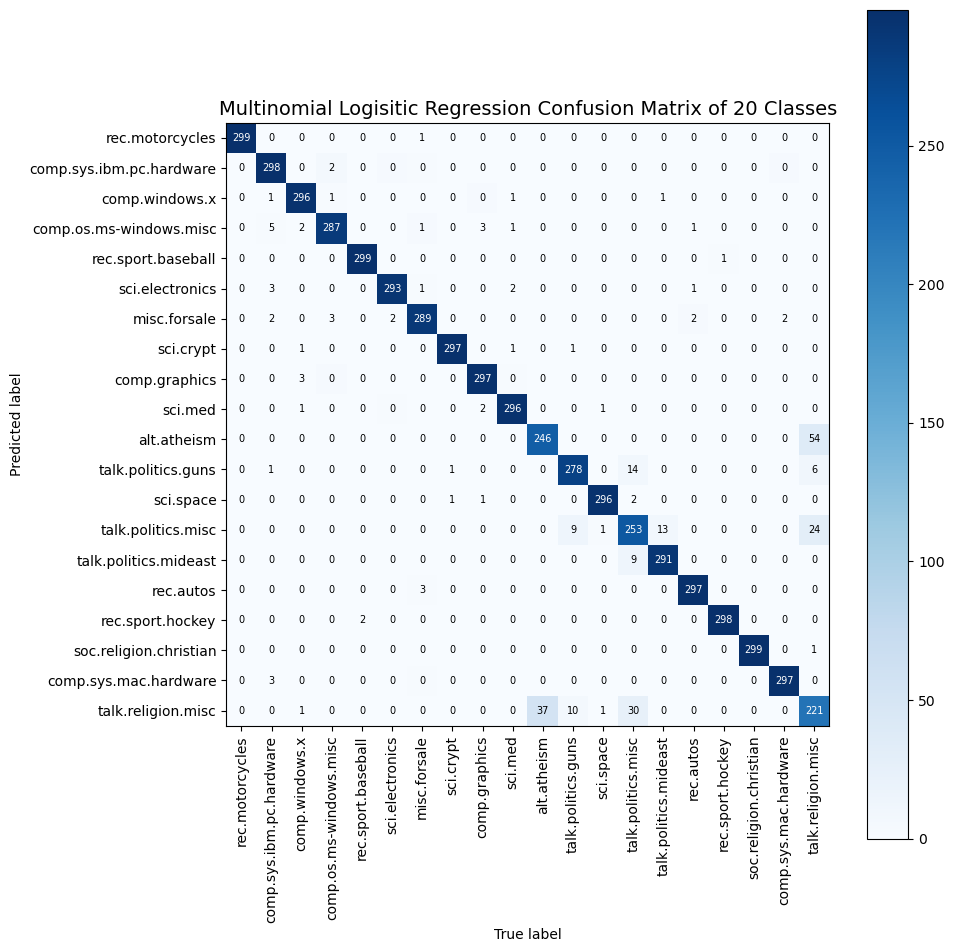

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Multinomial Logisitic Regression Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()

In [35]:
cm = confusion_matrix.copy()
np.fill_diagonal(cm, 0)

most_confused = np.unravel_index(np.argmax(cm), cm.shape)

true_class = classes[most_confused[0]]
pred_class = classes[most_confused[1]]
count = cm[most_confused]

print(f"Most confused pair: {true_class} → {pred_class} ({count} times)")

Most confused pair: talk.religion.misc → alt.atheism (54 times)
